In [62]:
import cv2
import numpy as np
from show_img import show_img

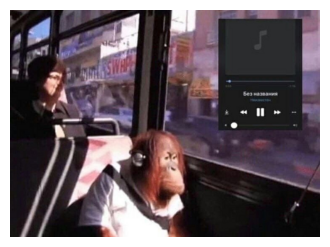

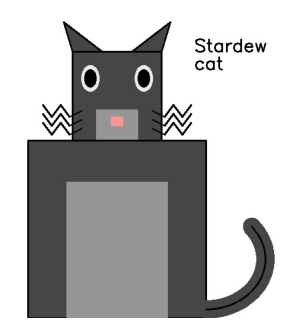

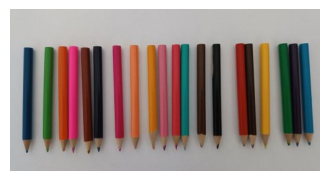

In [63]:
img1 = cv2.imread("bibizyana.jpg")
img2 = cv2.imread("my_cat.jpg")
img3 = cv2.imread("pencils1_500.jpg")
img4 = cv2.imread("railway_carriage.jpg")
show_img(img1, size=4)
show_img(img2, size=4)
show_img(img3, size=4)

## Обработка изображения: Эрозия, дилатация, открытие, закрытие, морф. градиент, преобразования tophat and blackhat

In [ ]:
def different_transformations(img: cv2.typing.MatLike, 
                              grayscale=False, thres=False,
                              kernel_s1 = (7, 7),
                              kernel_s2 = (21, 21)):
    size = 6
    imgs = []
    titles = ["erosion", "dilation", "opening", "closing", 
              "gradient", "tophat", "blackhat"]
    
    img_to_transform = img.copy()
    if grayscale or thres:
        img_to_transform = cv2.cvtColor(img_to_transform, cv2.COLOR_BGR2GRAY)
    if thres:
        _, img_to_transform = cv2.threshold(img_to_transform, 127, 255, cv2.THRESH_BINARY)
    show_img(img_to_transform, "default", size=size)

    kernel = np.ones((5,5),np.uint8)

    imgs.append(cv2.erode(img_to_transform, kernel, iterations=1))
    imgs.append(cv2.dilate(img_to_transform, kernel, iterations=1))
    imgs.append(cv2.morphologyEx(img_to_transform, cv2.MORPH_OPEN, kernel))
    imgs.append(cv2.morphologyEx(img_to_transform, cv2.MORPH_CLOSE, kernel))
    imgs.append(cv2.morphologyEx(img_to_transform, cv2.MORPH_GRADIENT, kernel))
    imgs.append(cv2.morphologyEx(img_to_transform, cv2.MORPH_TOPHAT, 
                                            np.ones(kernel_s1,np.uint8)))
    imgs.append(cv2.morphologyEx(img_to_transform, cv2.MORPH_BLACKHAT, 
                                              np.ones(kernel_s2,np.uint8)))

    '''
    img_erode = cv2.erode(img_to_transform, kernel, iterations=1)
    show_img(img_erode, "erosion", size=size)

    img_dilate = cv2.dilate(img_to_transform, kernel, iterations=1)
    show_img(img_dilate, "dilation", size=size)

    img_open = cv2.morphologyEx(img_to_transform, cv2.MORPH_OPEN, kernel)
    show_img(img_open, "opening", size=size)

    img_close = cv2.morphologyEx(img_to_transform, cv2.MORPH_CLOSE, kernel)
    show_img(img_close, "closing", size=size)

    img_grad = cv2.morphologyEx(img_to_transform, cv2.MORPH_GRADIENT, kernel)
    show_img(img_grad, "gradient", size=size)

    img_toph = cv2.morphologyEx(img_to_transform, cv2.MORPH_TOPHAT, kernel)
    show_img(img_toph, "tophat", size=size)

    img_blackh = cv2.morphologyEx(img_to_transform, cv2.MORPH_BLACKHAT, kernel)
    show_img(img_blackh, "blackhat", size=size)
    '''

    for i in range(min(len(imgs), len(titles))):
        show_img(imgs[i], titles[i], size=size)



## Изображение 1: Обезьяна

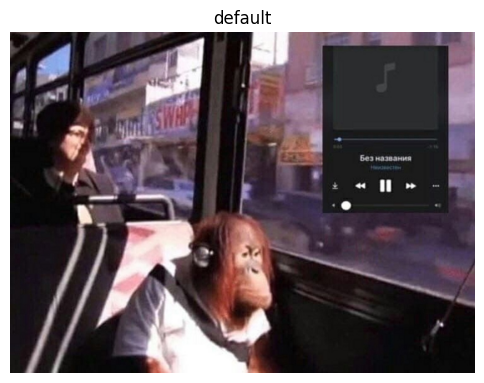

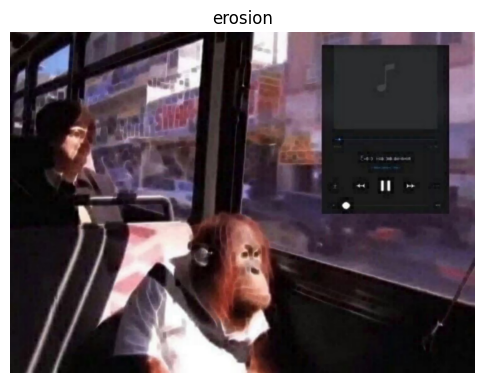

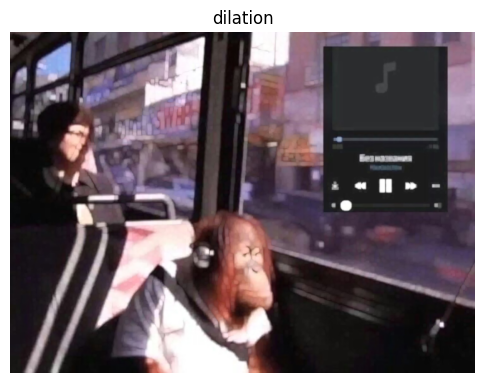

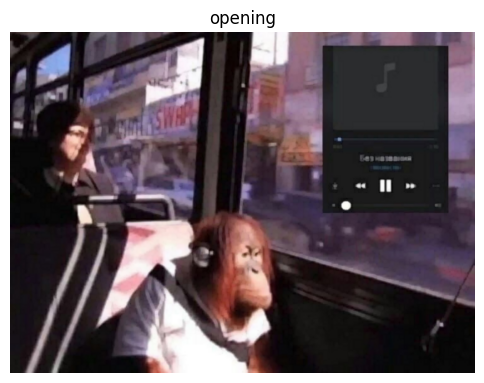

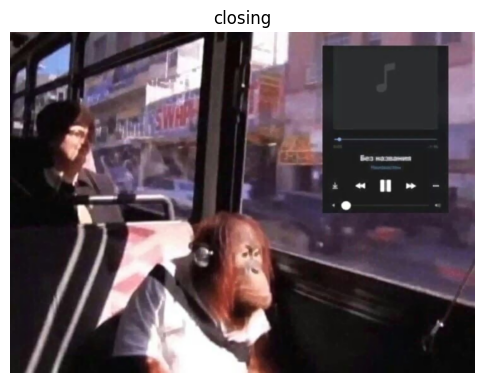

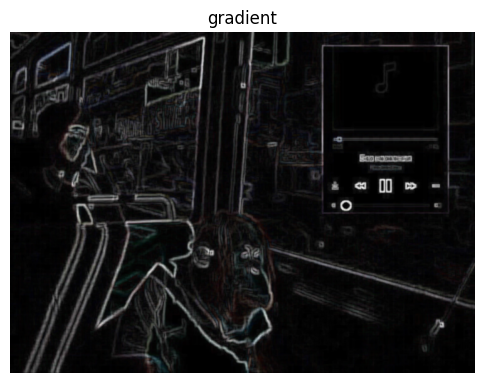

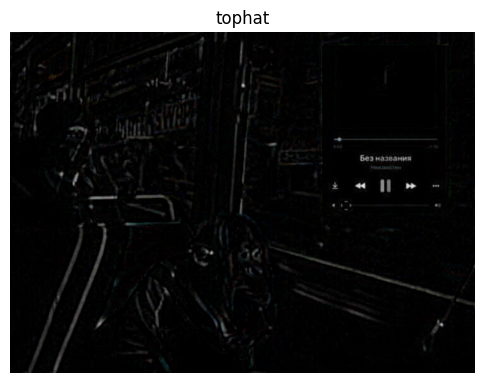

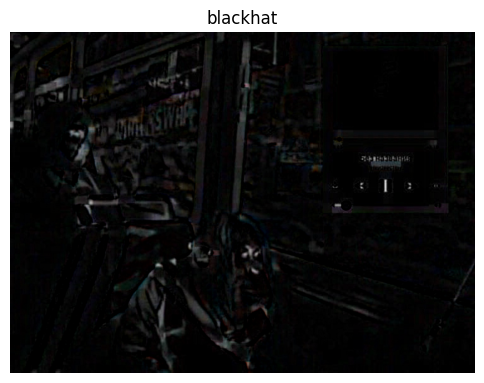

In [65]:
different_transformations(img1, thres=False, kernel_s1=(11, 11))

## Изображение 2: Нарисованный кот

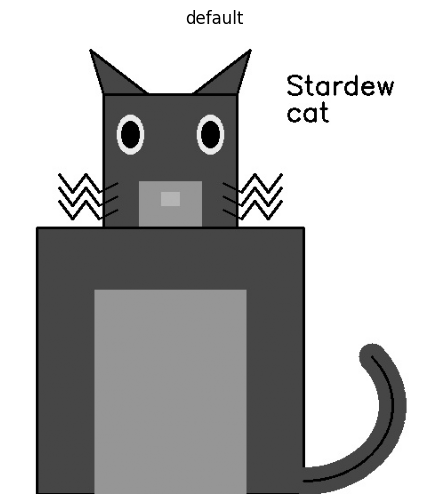

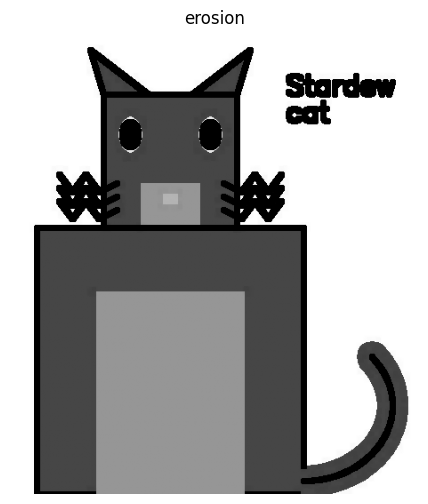

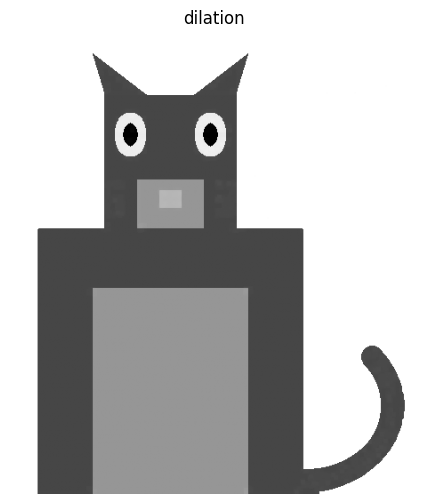

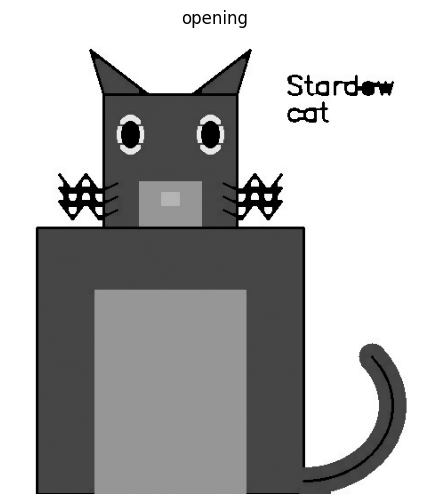

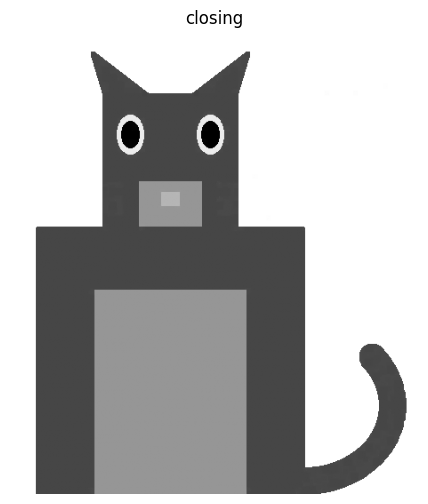

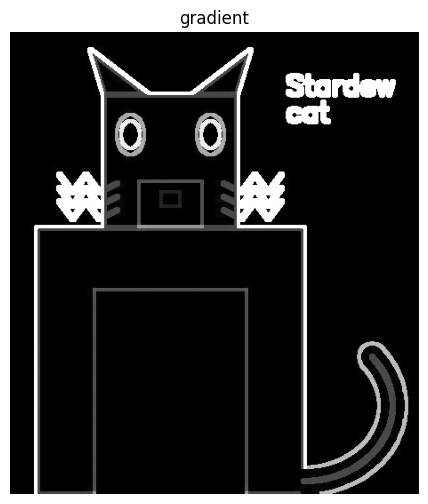

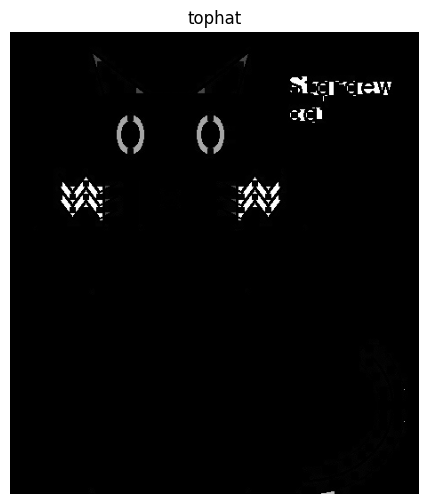

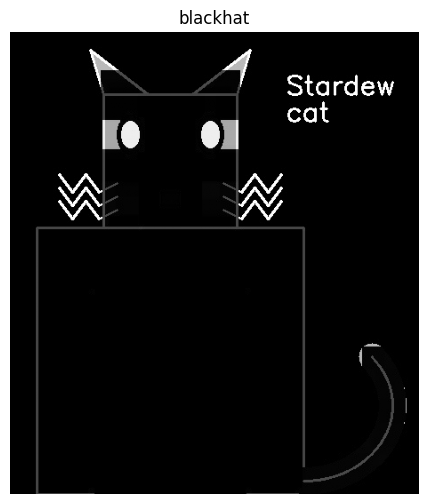

In [66]:
different_transformations(img2, grayscale=True)

## Изображение 3: Тестовое изображение карандашей 

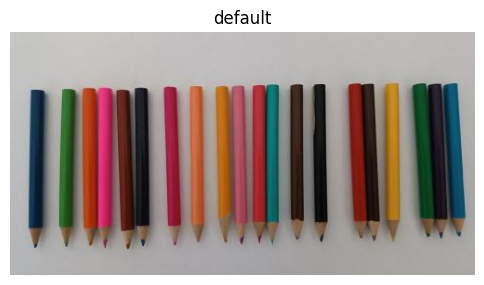

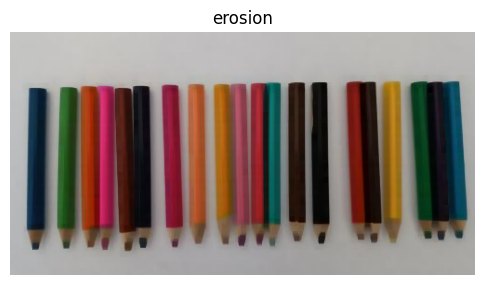

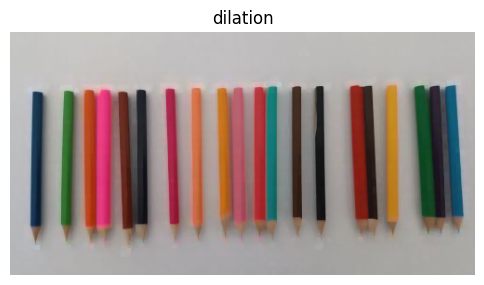

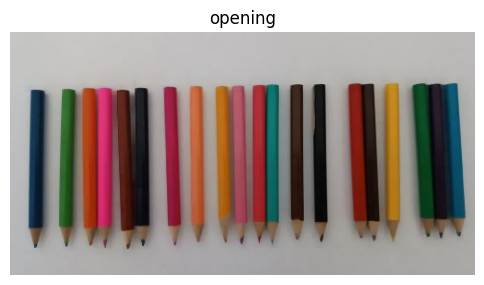

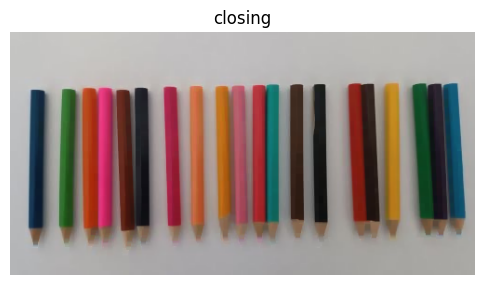

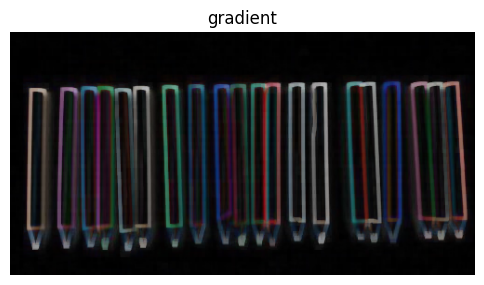

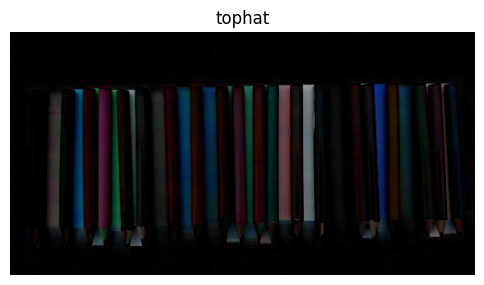

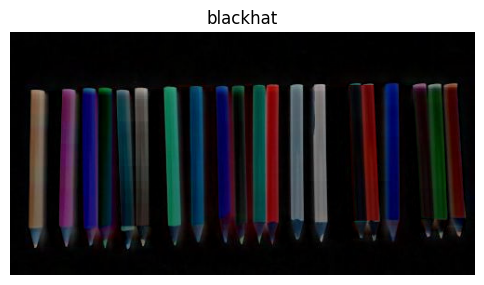

In [67]:
different_transformations(img3, kernel_s1=(15, 15))

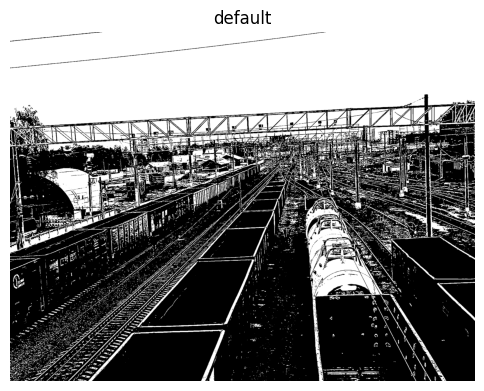

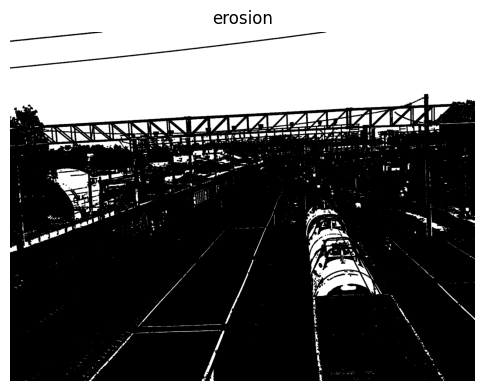

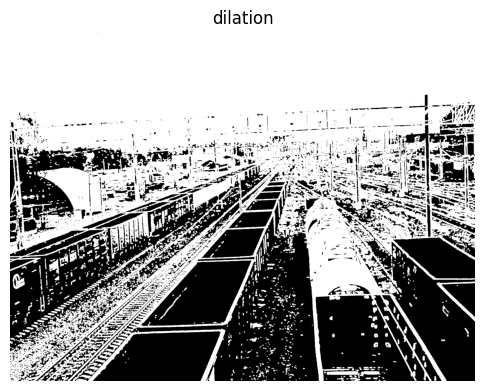

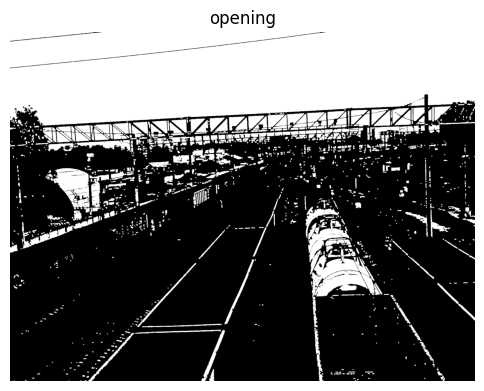

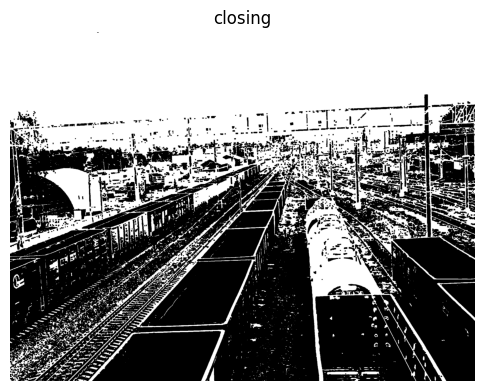

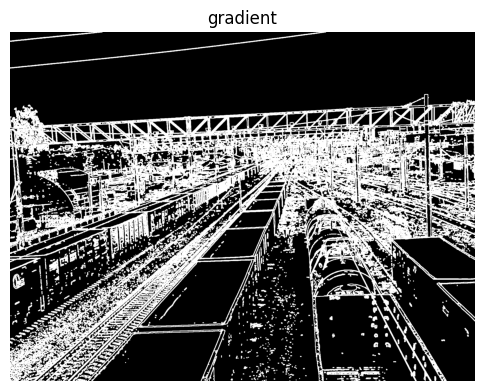

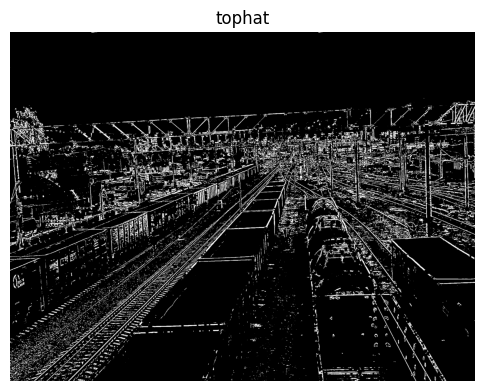

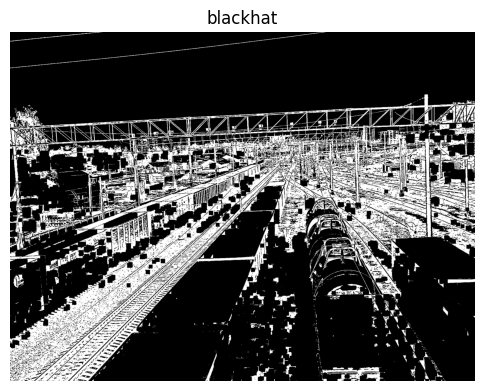

In [68]:
different_transformations(img4, thres=True)